# Fine-tuning LoRA — GPT-2 Português (tema: Saúde)

Notebook para a Aula 3 / trabalho final. Ajusta `pierreguillou/gpt2-small-portuguese` com LoRA
usando a base `saude.jsonl` (1.200 pares instrução/resposta).

**Antes de rodar:** ative GPU em `Ambiente de execução > Alterar tipo de ambiente > GPU`.
Faz upload de `saude.jsonl` para o mesmo diretório deste notebook (ou ajuste `CAMINHO_BASE` abaixo).

O que este notebook faz, além do mínimo da Aula 3:
- Separa uma fatia de validação (10%) pra você ver se o modelo está decorando ou generalizando.
- Expõe épocas, taxa de aprendizado, tamanho do lote e comprimento máximo como variáveis no topo — são os parâmetros que a aplicação final precisa deixar o usuário mexer.
- Guarda a perda de treino *e* de validação a cada época e plota as duas.
- Roda um conjunto fixo de perguntas de teste ao final, antes e depois de existir o modelo treinado, pra comparar.


## 1. Instalar bibliotecas

In [1]:
!pip install -q transformers peft accelerate matplotlib



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Parâmetros configuráveis

Estes são os parâmetros que a interface da aplicação final deve expor ao usuário (ver enunciado).
Mude aqui para experimentar antes de ligar isso à UI.

In [2]:
# --- parâmetros de TREINO ---
EPOCAS = 3                 # quantas vezes o modelo vê a base inteira
TAXA_APRENDIZADO = 5e-4    # tamanho do passo do ajuste
TAMANHO_LOTE = 4           # exemplos por passo (batch size)
MAX_LENGTH = 128           # comprimento máximo (em tokens) de cada exemplo formatado

# --- outros ---
CAMINHO_BASE = 'saude.jsonl'   # troque pelo arquivo do seu grupo (tecnologia.jsonl, negocios.jsonl, ...)
FRACAO_VALIDACAO = 0.10        # 10% dos pares ficam de fora do treino, só para medir a perda
SEED = 42
PASTA_SAIDA = 'meu_modelo'


## 3. Carregar o modelo base e o tokenizador

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, PeftModel
import torch, json, time, random

random.seed(SEED)
torch.manual_seed(SEED)

BASE = 'pierreguillou/gpt2-small-portuguese'
tok = AutoTokenizer.from_pretrained(BASE)
tok.pad_token = tok.eos_token

modelo = AutoModelForCausalLM.from_pretrained(BASE)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
modelo.to(device)
print('dispositivo:', device)


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


dispositivo: cpu


## 4. Ligar o LoRA

O LoRA congela o modelo inteiro e treina só umas matrizes pequenas nas camadas de atenção
(`c_attn`). Com `r=8` isso fica em torno de 0,24% dos parâmetros do modelo — é por isso que
o treino cabe em poucos minutos, mesmo em CPU.

In [4]:
cfg = LoraConfig(r=8, lora_alpha=16, target_modules=['c_attn'],
                 lora_dropout=0.05, task_type='CAUSAL_LM')
modelo = get_peft_model(modelo, cfg)
modelo.print_trainable_parameters()


trainable params: 294,912 || all params: 124,734,720 || trainable%: 0.2364


c:\Users\caioc\AppData\Local\Programs\Python\Python314\Lib\site-packages\peft\tuners\lora\layer.py:2631: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## 5. Carregar e inspecionar a base

Leia o README que veio com a base antes de treinar — ele explica os defeitos deixados de
propósito (erros de tradução, `input` quase sempre vazio) e o filtro temático aplicado.

In [5]:
with open(CAMINHO_BASE, encoding='utf-8') as f:
    pares = [json.loads(l) for l in f]

print(f'{len(pares)} pares carregados de {CAMINHO_BASE}')
print()
print('exemplo:')
print(json.dumps(pares[0], indent=2, ensure_ascii=False))

vazio = sum(1 for p in pares if not p.get('input', '').strip())
print(f'\ninput vazio em {vazio/len(pares)*100:.1f}% dos pares')


1200 pares carregados de saude.jsonl

exemplo:
{
  "instruction": "Fornecer uma definição da palavra \"vacinação\".",
  "input": "",
  "output": "A oscilação é o estado de hesitação ou oscilação entre decisões ou ações. É caracterizada por uma incapacidade de tomar uma decisão ou compromisso firme."
}

input vazio em 87.7% dos pares


In [6]:
# separação treino / validação — embaralha antes de cortar
random.shuffle(pares)
corte = int(len(pares) * (1 - FRACAO_VALIDACAO))
pares_treino, pares_val = pares[:corte], pares[corte:]
print(f'treino: {len(pares_treino)}   validação: {len(pares_val)}')


treino: 1080   validação: 120


## 6. Formatar os pares

O modelo não sabe o que é pergunta e o que é resposta — isso precisa ser marcado com um
formato fixo. **Use exatamente este mesmo formato na hora de conversar** (célula 10), senão
o modelo não reconhece o padrão.

Quando `input` não está vazio, ele entra como contexto extra antes da pergunta.

In [7]:
def formatar(p):
    contexto = f"### Contexto:\n{p['input']}\n\n" if p.get('input', '').strip() else ''
    return (f"{contexto}### Pergunta:\n{p['instruction']}\n\n"
            f"### Resposta:\n{p['output']}{tok.eos_token}")

print(formatar(pares_treino[0]))


### Pergunta:
Crie um pôster com os benefícios de comer saudável.

### Resposta:
Um cartaz com os benefícios da alimentação saudável provavelmente enfatizaria um equilíbrio de nutrientes. Ele poderia mostrar uma variedade de alimentos como vegetais, frutas e grãos, bem como carnes magras e peixes, laticínios e gorduras saudáveis. O cartaz poderia ter um slogan como “Coma Saudável; Sinta-se Incrível” e uma caixa de texto listando alguns dos benefícios da alimentação saudável, como aumento de energia, melhor humor e menor risco de condições graves de saúde.<|endoftext|>


## 7. Tokenizar

In [8]:
def tokenizar(lista_pares):
    enc = tok([formatar(p) for p in lista_pares], truncation=True, max_length=MAX_LENGTH,
              padding='max_length', return_tensors='pt')
    return enc['input_ids'].to(device), enc['attention_mask'].to(device)

X_treino, M_treino = tokenizar(pares_treino)
X_val, M_val = tokenizar(pares_val)
print(X_treino.shape, X_val.shape)


torch.Size([1080, 128]) torch.Size([120, 128])


## 8. Treinar

Acompanhe a perda de treino e de validação a cada época:
- se as duas descem juntas, o modelo está aprendendo o tema.
- se a perda de treino desce e a de validação sobe (ou para de descer), o modelo começou a
  decorar a base em vez de generalizar — é sinal para reduzir épocas.
- se a perda oscila sem sair do lugar, a taxa de aprendizado provavelmente está alta demais.

In [9]:
@torch.no_grad()
def perda_media(X, M):
    modelo.eval()
    total, n = 0.0, 0
    for k in range(0, len(X), TAMANHO_LOTE):
        xb, mb = X[k:k+TAMANHO_LOTE], M[k:k+TAMANHO_LOTE]
        lb = xb.clone(); lb[mb == 0] = -100
        out = modelo(input_ids=xb, attention_mask=mb, labels=lb)
        total += out.loss.item() * len(xb); n += len(xb)
    return total / n

opt = torch.optim.AdamW([p for p in modelo.parameters() if p.requires_grad], lr=TAXA_APRENDIZADO)

historico_treino, historico_val = [], []
t0 = time.time()

for epoca in range(EPOCAS):
    modelo.train()
    perdas_passo = []
    ordem = list(range(0, len(X_treino), TAMANHO_LOTE))
    random.shuffle(ordem)
    for k in ordem:
        xb, mb = X_treino[k:k+TAMANHO_LOTE], M_treino[k:k+TAMANHO_LOTE]
        lb = xb.clone(); lb[mb == 0] = -100
        opt.zero_grad()
        out = modelo(input_ids=xb, attention_mask=mb, labels=lb)
        out.loss.backward()
        opt.step()
        perdas_passo.append(out.loss.item())

    perda_treino_epoca = sum(perdas_passo) / len(perdas_passo)
    perda_val_epoca = perda_media(X_val, M_val)
    historico_treino.append(perda_treino_epoca)
    historico_val.append(perda_val_epoca)
    print(f'época {epoca+1}/{EPOCAS}   perda treino {perda_treino_epoca:.3f}   perda validação {perda_val_epoca:.3f}')

modelo.eval()
print(f'\ntreinado em {time.time()-t0:.0f}s')


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


época 1/3   perda treino 2.720   perda validação 2.357
época 2/3   perda treino 2.498   perda validação 2.290
época 3/3   perda treino 2.414   perda validação 2.243

treinado em 2120s


## 9. Gráfico da perda

Vale mais na apresentação do que qualquer print de conversa.

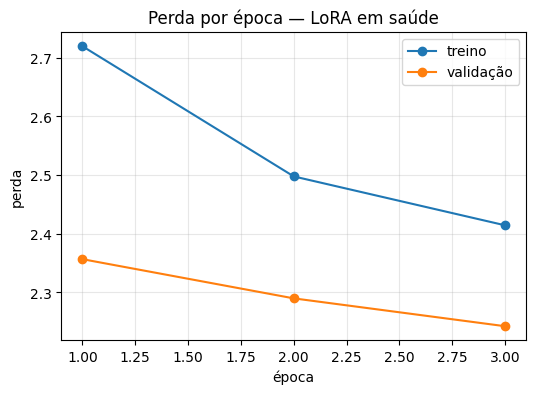

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(1, EPOCAS+1), historico_treino, marker='o', label='treino')
plt.plot(range(1, EPOCAS+1), historico_val, marker='o', label='validação')
plt.xlabel('época')
plt.ylabel('perda')
plt.title('Perda por época — LoRA em saúde')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('curva_perda.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Salvar o adaptador treinado

Isso salva só o adaptador LoRA (poucos megabytes), não o modelo base inteiro.

In [11]:
modelo.save_pretrained(PASTA_SAIDA)
tok.save_pretrained(PASTA_SAIDA)
print(f'salvo em ./{PASTA_SAIDA}')


salvo em ./meu_modelo


## 11. Recarregar e conversar

Esta é a função que a aplicação final deve chamar. `temperatura` e `penalidade` são os dois
parâmetros de conversa que a interface precisa expor.

In [12]:
# recarregar do zero, como a aplicação final vai fazer
base = AutoModelForCausalLM.from_pretrained(BASE)
modelo_final = PeftModel.from_pretrained(base, PASTA_SAIDA).to(device)
modelo_final.eval()

def responder(pergunta, contexto='', temperatura=0.8, penalidade=1.2, n=80):
    prefixo = f"### Contexto:\n{contexto}\n\n" if contexto.strip() else ''
    p = f"{prefixo}### Pergunta:\n{pergunta}\n\n### Resposta:\n"
    ids = tok(p, return_tensors='pt').to(device)
    with torch.no_grad():
        o = modelo_final.generate(**ids, max_new_tokens=n, do_sample=True,
                            temperature=temperatura, top_p=0.9,
                            repetition_penalty=penalidade,
                            no_repeat_ngram_size=3,
                            pad_token_id=tok.eos_token_id)
    saida = tok.decode(o[0], skip_special_tokens=True)
    return saida.split('### Resposta:')[-1].strip()


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 12. Teste rápido

Um conjunto fixo de perguntas pra comparar entre rodadas de treino.

In [13]:
perguntas_teste = [
    'Como posso reduzir o estresse no dia a dia?',
    'O que é hipertensão?',
    'Quais são os benefícios de uma boa noite de sono?',
    'Explique o que é vacinação.',
]

for pergunta in perguntas_teste:
    print('P:', pergunta)
    print('R:', responder(pergunta))
    print()


P: Como posso reduzir o estresse no dia a dia?
R: Pode ser feito comer um pouco de comida equilibrada e uma dieta leve. Além disso, pode estar normal fazer exercícios regulares como andar ou sentar em camas com pesos baixos que permitam relaxar durante as sessões diárias. Que os Estados Unidos estão se tornando cada vez mais intoxicados são exemplos de mudanças nas políticas públicas contemporâneas da América Latina. (; ; ) é um ex-futebolista italiano que atuava

P: O que é hipertensão?
R: A hipertensão pode ser causada pela doença cardíaca ou cardíaco e pelo acúmulo de colesterol. não tem efeitos colaterais graves, como doenças cardíacas crônicas e cardiovasculares sérias. também está associada a problemas cardíacos significativos, incluindo diabetes e hipertensão arterial. produz um número muito reduzido de enzimas importantes que podem afetar o metabolismo do corpo humano e causar efeitos adversos no sistema nervoso simpático e na pele, causando danos nos neurônios

P: Quais são os

## Notas para a análise / apresentação

- Se o modelo repete a mesma frase sem parar: suba `penalidade` (repetition_penalty). Se persistir mesmo em `n` baixo, treine mais épocas.
- Se o modelo não para de escrever: confira se `tok.eos_token` está mesmo no fim de todo exemplo formatado (célula 6).
- Se responde fora do tema: normalmente é `EPOCAS` baixo — suba antes de mexer em qualquer outro parâmetro.
- Se copia a pergunta na resposta: o formato usado em `formatar()` (treino) e em `responder()` (conversa) ficou diferente — compare os dois com cuidado.
- Se fala coisa errada com confiança: é esperado, a base tem erros de tradução herdados do Alpaca original e o modelo aprende o erro do dado. Mostre isso na apresentação, com exemplo, em vez de esconder.
- Lembrete das duas regras do trabalho: nada de API de LLM (ChatGPT/Gemini/Claude) rodando dentro da aplicação final — o modelo que conversa tem que ser este adaptador treinado por vocês; e a base (`saude.jsonl`) não entra no zip de entrega, só o código, o modelo treinado e o README.
